In [3]:
#Import des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [4]:
#chargement du dataset
iris=load_iris()
X=iris.data #variables explicatives
Y=iris.target
feature_names=iris.feature_names
class_names=iris.target_names
print("Dimension de X:",X.shape)
print("Dimension de Y:",Y.shape)


Dimension de X: (150, 4)
Dimension de Y: (150,)


In [5]:
#Séparation train et test
(X_train,X_test,Y_train,Y_test)=train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)

In [6]:
#Création du modèle Arbre de Décision
dt_model=DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

In [7]:
#Entraînement du modèle
dt_model.fit(X_train,Y_train)
#Prédictions
Y_pred=dt_model.predict(X_test)

In [9]:
#Evaluation du modèle
accuracy=accuracy_score(Y_test,Y_pred)
print("Accuracy du modèle:",accuracy)
print("Matrice de confusion:")
print(confusion_matrix(Y_test,Y_pred))
print("Rapport de classification:")
print(classification_report(Y_test,Y_pred))


Accuracy du modèle: 0.9333333333333333
Matrice de confusion:
[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]
Rapport de classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.80      0.89        15
           2       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



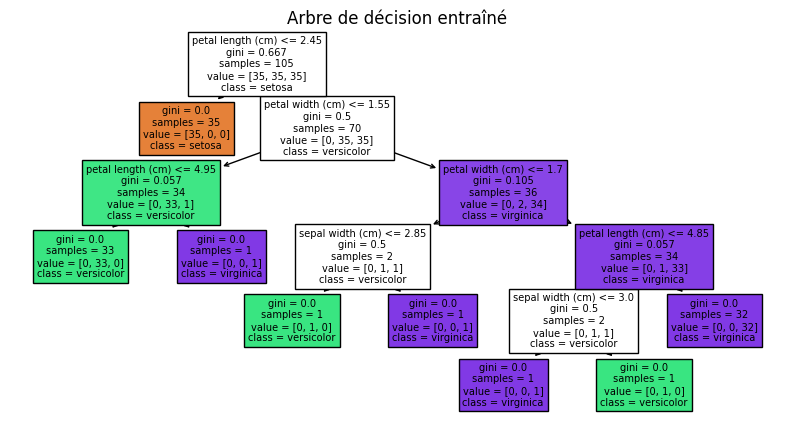

In [10]:
# Visualisation de l’arbre de décision
plt.figure(figsize=(10,5))
plot_tree(dt_model,feature_names=feature_names,class_names=class_names,filled=True)
plt.title("Arbre de décision entraîné")
plt.show()

In [12]:
#Importance des variables
importances=dt_model.feature_importances_
importance_df=pd.DataFrame({
    "Feature":feature_names,
    "Importance":importances}

).sort_values(by="Importance",ascending=False)
print(importance_df)

             Feature  Importance
2  petal length (cm)    0.541176
3   petal width (cm)    0.430252
1   sepal width (cm)    0.028571
0  sepal length (cm)    0.000000


In [13]:
#Lutter contre le surapprentissage
dt_model_ameliore=DecisionTreeClassifier(criterion="gini",
max_depth=3,
random_state=42)
dt_model_ameliore.fit(X_train,Y_train)
Y_pred_2=dt_model_ameliore.predict(X_test)
print("Accuracy de l'arbre de décision non limité:",accuracy)
print("Accuracy de l'arbre de décision limité:",accuracy_score(Y_test,Y_pred_2))

Accuracy de l'arbre de décision non limité: 0.9333333333333333
Accuracy de l'arbre de décision limité: 0.9777777777777777
